In [1]:
import pandas as pd
import numpy as np  
import sys
!{sys.executable} -m pip install xgboost
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor     
# Load supply chain dataset
df = pd.read_csv("supply_chain_dataset1.csv")

# Quick preview
df.head()


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10.0,592.0,14.0,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17.0,575.0,14.0,379,0,13.95,20.48,0,0,NaN
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35.0,540.0,14.0,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24.0,516.0,14.0,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21.0,495.0,14.0,379,0,13.95,20.48,0,0,18.70


In [2]:
df.isnull().sum()

Date                         0
SKU_ID                       0
Warehouse_ID                 0
Supplier_ID                  0
Region                     414
Units_Sold                 408
Inventory_Level            402
Supplier_Lead_Time_Days    411
Reorder_Point                0
Order_Quantity               0
Unit_Cost                    0
Unit_Price                   0
Promotion_Flag               0
Stockout_Flag                0
Demand_Forecast            487
dtype: int64

In [3]:
# Keep first 8000 rows for faster EDA / prototyping
df = df.iloc[:8000]

# Save a smaller working dataset
df.to_csv("supply_chain_data_8000.csv", index=False)


**Making the dataset dirty so that preprocessing and feature engineer can be applied**


We intentionally messed up the dataset to simulate real-world retail data quality issues by introducing 

1) Missing values, 
2) Duplicates,
3) Invalid strings,
4) Negatives, and
5) Outliers.


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings("ignore")

################################################################
INPUT_FILE = "supply_chain_data_8000.csv"      # clean sample dataset
OUTPUT_DIRTY_FILE = "supply_chain_data_dirty.csv"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -----------------------------
# Load clean dataset
# -----------------------------
df = pd.read_csv(INPUT_FILE)
print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

# -----------------------------
# 1) Introduce missing values
# -----------------------------
missing_frac = 0.05  # 5% missing per selected column

cols_to_null = [
    "Units_Sold",
    "Inventory_Level",
    "Demand_Forecast",
    "Supplier_Lead_Time_Days",
    "Region"
]

for col in cols_to_null:
    if col in df.columns:
        idx = df.sample(frac=missing_frac,
                        random_state=np.random.randint(0, 1_000_000)).index
        df.loc[idx, col] = np.nan

# -----------------------------
# 2) Introduce duplicate rows
# -----------------------------
dup_frac = 0.03  # 3% duplicated
dup_rows = df.sample(frac=dup_frac, random_state=np.random.randint(0, 1_000_000))
df_dirty = pd.concat([df, dup_rows], ignore_index=True)
print("After adding duplicates shape:", df_dirty.shape)

# -----------------------------
# 3) Introduce outliers
# -----------------------------
outlier_frac = 0.01  # 1% rows as outliers
outlier_idx = df_dirty.sample(frac=outlier_frac,
                              random_state=np.random.randint(0, 1_000_000)).index

# Inflate Units_Sold (spikes)
if "Units_Sold" in df_dirty.columns:
    df_dirty.loc[outlier_idx, "Units_Sold"] = (
        pd.to_numeric(df_dirty.loc[outlier_idx, "Units_Sold"], errors="coerce")
        .fillna(1) * np.random.randint(5, 15, size=len(outlier_idx))
    )

# Inflate Inventory_Level (sudden large stock)
if "Inventory_Level" in df_dirty.columns:
    df_dirty.loc[outlier_idx, "Inventory_Level"] = (
        pd.to_numeric(df_dirty.loc[outlier_idx, "Inventory_Level"], errors="coerce")
        .fillna(10) * np.random.randint(3, 10, size=len(outlier_idx))
    )

# Inflate Demand_Forecast (crazy forecast values)
if "Demand_Forecast" in df_dirty.columns:
    df_dirty.loc[outlier_idx, "Demand_Forecast"] = (
        pd.to_numeric(df_dirty.loc[outlier_idx, "Demand_Forecast"], errors="coerce")
        .fillna(1.0) * np.random.uniform(3, 10, size=len(outlier_idx))
    )

# -----------------------------
# 4) Introduce negative values (invalid for many supply chain metrics)
# -----------------------------
neg_frac = 0.005  # 0.5% rows
neg_idx = df_dirty.sample(frac=neg_frac,
                          random_state=np.random.randint(0, 1_000_000)).index

for col in ["Units_Sold", "Inventory_Level", "Demand_Forecast", "Order_Quantity", "Unit_Price", "Unit_Cost"]:
    if col in df_dirty.columns:
        df_dirty.loc[neg_idx, col] = -abs(
            pd.to_numeric(df_dirty.loc[neg_idx, col], errors="coerce").fillna(1)
        )

# -----------------------------
# 5) Introduce invalid string values into numeric columns
# -----------------------------
string_frac = 0.01  # 1% rows
string_idx = df_dirty.sample(frac=string_frac,
                             random_state=np.random.randint(0, 1_000_000)).index

if "Demand_Forecast" in df_dirty.columns:
    df_dirty.loc[string_idx, "Demand_Forecast"] = "N/A"

string_idx2 = df_dirty.sample(frac=string_frac,
                              random_state=np.random.randint(0, 1_000_000)).index

if "Units_Sold" in df_dirty.columns:
    df_dirty.loc[string_idx2, "Units_Sold"] = "missing"

# -----------------------------
# 6) Introduce invalid categories (dirty categorical values)
# -----------------------------
cat_frac = 0.01
cat_idx = df_dirty.sample(frac=cat_frac,
                          random_state=np.random.randint(0, 1_000_000)).index

if "Region" in df_dirty.columns:
    df_dirty.loc[cat_idx, "Region"] = "??UNKNOWN??"

# -----------------------------
# 7) Mess up some dates (bad parsing)
# -----------------------------
date_frac = 0.005
date_idx = df_dirty.sample(frac=date_frac,
                           random_state=np.random.randint(0, 1_000_000)).index

if "Date" in df_dirty.columns:
    df_dirty.loc[date_idx, "Date"] = "not_a_date"

# -----------------------------
# Save dirty dataset
# -----------------------------
df_dirty.to_csv(OUTPUT_DIRTY_FILE, index=False)
print(f"Dirty dataset saved to: {OUTPUT_DIRTY_FILE}")
print("Dirty shape:", df_dirty.shape)


Original shape: (8000, 15)
Columns: ['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']
After adding duplicates shape: (8240, 15)
Dirty dataset saved to: supply_chain_data_dirty.csv
Dirty shape: (8240, 15)


In [5]:
import pandas as pd

df_dirty = pd.read_csv("supply_chain_data_dirty.csv")
df_dirty.head()


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10.0,592.0,14.0,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17.0,575.0,14.0,379,0,13.95,20.48,0,0,NaN
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35.0,540.0,14.0,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24.0,516.0,14.0,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21.0,495.0,14.0,379,0,13.95,20.48,0,0,18.70


In [6]:
df_dirty.isnull().sum()

Date                         0
SKU_ID                       0
Warehouse_ID                 0
Supplier_ID                  0
Region                     414
Units_Sold                 408
Inventory_Level            402
Supplier_Lead_Time_Days    411
Reorder_Point                0
Order_Quantity               0
Unit_Cost                    0
Unit_Price                   0
Promotion_Flag               0
Stockout_Flag                0
Demand_Forecast            488
dtype: int64

In [7]:
df_dirty.describe()

,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,7838.000000,7829.000000,8240.000000,8240.000000,8240.000000,8240.000000,8240.000000,8240.0,7752.00000
mean,644.486859,9.192873,302.290291,19.395388,12.204802,18.690757,0.098180,0.0,28.98671
std,2147.982185,3.451999,47.474614,82.717002,4.809725,7.633565,0.297575,0.0,112.05902
min,-708.000000,2.000000,228.000000,-381.000000,-19.760000,-35.100000,0.000000,0.0,-35.29000
25%,373.000000,7.000000,260.000000,0.000000,7.720000,11.620000,0.000000,0.0,12.89750
50%,465.000000,9.000000,298.000000,0.000000,12.740000,19.920000,0.000000,0.0,20.09000
75%,569.000000,13.000000,338.000000,0.000000,16.030000,23.470000,0.000000,0.0,27.24000
max,49167.000000,14.000000,379.000000,498.000000,19.760000,35.100000,1.000000,0.0,2688.47527


## Check basic info & data types


In [8]:
print("\n=== INFO ===")
print(df_dirty.info())

print("\n=== HEAD ===")
print(df_dirty.head())



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     8240 non-null   object 
 1   SKU_ID                   8240 non-null   object 
 2   Warehouse_ID             8240 non-null   object 
 3   Supplier_ID              8240 non-null   object 
 4   Region                   7826 non-null   object 
 5   Units_Sold               7832 non-null   object 
 6   Inventory_Level          7838 non-null   float64
 7   Supplier_Lead_Time_Days  7829 non-null   float64
 8   Reorder_Point            8240 non-null   int64  
 9   Order_Quantity           8240 non-null   int64  
 10  Unit_Cost                8240 non-null   float64
 11  Unit_Price               8240 non-null   float64
 12  Promotion_Flag           8240 non-null   int64  
 13  Stockout_Flag            8240 non-null   int64  
 14  Demand_For

## Checking missing values


In [9]:
print("\n=== Missing value percentage ===")
missing_pct = df_dirty.isna().mean() * 100
print(missing_pct.round(2))



=== Missing value percentage ===
Date                       0.00
SKU_ID                     0.00
Warehouse_ID               0.00
Supplier_ID                0.00
Region                     5.02
Units_Sold                 4.95
Inventory_Level            4.88
Supplier_Lead_Time_Days    4.99
Reorder_Point              0.00
Order_Quantity             0.00
Unit_Cost                  0.00
Unit_Price                 0.00
Promotion_Flag             0.00
Stockout_Flag              0.00
Demand_Forecast            5.92
dtype: float64


In [10]:
print("\n= Missing values per column =")
print(df_dirty.isna().sum())



= Missing values per column =
Date                         0
SKU_ID                       0
Warehouse_ID                 0
Supplier_ID                  0
Region                     414
Units_Sold                 408
Inventory_Level            402
Supplier_Lead_Time_Days    411
Reorder_Point                0
Order_Quantity               0
Unit_Cost                    0
Unit_Price                   0
Promotion_Flag               0
Stockout_Flag                0
Demand_Forecast            488
dtype: int64


## Check duplicates

In [11]:
dup_count = df_dirty.duplicated().sum()
print(f"\n=== Duplicate rows: {dup_count} ===")

# Optional: view first few duplicate rows
if dup_count > 0:
    dup_rows = df_dirty[df_dirty.duplicated(keep=False)]
    print("\nSample duplicate rows:")
    display(dup_rows.head())



=== Duplicate rows: 228 ===

Sample duplicate rows:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18.0,477.0,14.0,379,0,13.95,20.48,0,0,18.33
39,2024-02-09,SKU_1,WH_1,SUP_8,South,28.0,508.0,14.0,379,0,13.95,20.48,0,0,27.93
61,2024-03-02,SKU_1,WH_1,SUP_8,South,NaN,483.0,14.0,379,0,13.95,20.48,0,0,22.75
84,2024-03-25,SKU_1,WH_1,SUP_8,West,29.0,490.0,14.0,379,0,13.95,20.48,0,0,31.27
121,2024-05-01,SKU_1,WH_1,SUP_8,South,41.0,633.0,14.0,379,0,13.95,20.48,1,0,45.43


## Detect invalid strings in numeric columns

In [12]:
# Numeric columns based on the supply chain dataset
numeric_cols = [
    "Units_Sold",
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Demand_Forecast"
]

print("\n=== Non-numeric values in numeric columns ===")
for col in numeric_cols:
    if col in df_dirty.columns:
        # Try converting to numeric, see which values fail
        coerced = pd.to_numeric(df_dirty[col], errors="coerce")
        mask_bad = coerced.isna() & df_dirty[col].notna()
        bad_values = df_dirty.loc[mask_bad, col].unique()

        if len(bad_values) > 0:
            print(f"\nColumn: {col}")
            print("Invalid values:", bad_values[:10])



=== Non-numeric values in numeric columns ===

Column: Units_Sold
Invalid values: ['missing']


## Check for negative values

In [13]:
print("\n=== Negative value counts ===")
for col in [
    "Units_Sold",
    "Inventory_Level",
    "Demand_Forecast",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price"
]:
    if col in df_dirty.columns:
        # Convert safely for check
        col_num = pd.to_numeric(df_dirty[col], errors="coerce")
        neg_count = (col_num < 0).sum()
        print(f"{col}: {neg_count} negatives")




=== Negative value counts ===
Units_Sold: 41 negatives
Inventory_Level: 42 negatives
Demand_Forecast: 40 negatives
Order_Quantity: 1 negatives
Unit_Cost: 42 negatives
Unit_Price: 42 negatives


## Viewing some of those bad rows

In [14]:
# Check for negative values in specified columns
for col in [
    "Units_Sold",
    "Inventory_Level",
    "Demand_Forecast",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price"
]:
    if col in df_dirty.columns:
        # Convert column to numeric, coercing errors to NaN
        col_num = pd.to_numeric(df_dirty[col], errors="coerce")

        # Identify rows with negative values
        bad_rows = df_dirty[col_num < 0]

        if not bad_rows.empty:
            print(f"\nSample rows with negative {col}:")
            display(bad_rows.head())



Sample rows with negative Units_Sold:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
32,2024-02-02,SKU_1,WH_1,SUP_8,West,-24.0,-696.0,14.0,379,0,-13.95,-20.48,0,0,-25.21
620,2024-09-12,SKU_1,WH_2,SUP_5,East,-12.0,-634.0,8.0,322,0,-11.46,-19.92,0,0,-14.01
763,2024-02-03,SKU_1,WH_3,SUP_9,East,-26.0,-1.0,6.0,314,0,-6.06,-8.41,0,0,-31.14
773,2024-02-13,SKU_1,WH_3,SUP_9,East,-31.0,-635.0,6.0,314,0,-6.06,-8.41,0,0,-33.87
805,2024-03-16,SKU_1,WH_3,SUP_9,East,-37.0,-458.0,6.0,314,0,-6.06,-8.41,1,0,-35.29



Sample rows with negative Inventory_Level:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
32,2024-02-02,SKU_1,WH_1,SUP_8,West,-24.0,-696.0,14.0,379,0,-13.95,-20.48,0,0,-25.21
620,2024-09-12,SKU_1,WH_2,SUP_5,East,-12.0,-634.0,8.0,322,0,-11.46,-19.92,0,0,-14.01
763,2024-02-03,SKU_1,WH_3,SUP_9,East,-26.0,-1.0,6.0,314,0,-6.06,-8.41,0,0,-31.14
773,2024-02-13,SKU_1,WH_3,SUP_9,East,-31.0,-635.0,6.0,314,0,-6.06,-8.41,0,0,-33.87
805,2024-03-16,SKU_1,WH_3,SUP_9,East,-37.0,-458.0,6.0,314,0,-6.06,-8.41,1,0,-35.29



Sample rows with negative Demand_Forecast:


...

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
5646,2024-06-20,SKU_4,WH_1,SUP_10,East,-19.0,-660.0,11.0,298,-381,-12.74,-15.44,0,0,-14.88



Sample rows with negative Unit_Cost:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
32,2024-02-02,SKU_1,WH_1,SUP_8,West,-24.0,-696.0,14.0,379,0,-13.95,-20.48,0,0,-25.21
620,2024-09-12,SKU_1,WH_2,SUP_5,East,-12.0,-634.0,8.0,322,0,-11.46,-19.92,0,0,-14.01
763,2024-02-03,SKU_1,WH_3,SUP_9,East,-26.0,-1.0,6.0,314,0,-6.06,-8.41,0,0,-31.14
773,2024-02-13,SKU_1,WH_3,SUP_9,East,-31.0,-635.0,6.0,314,0,-6.06,-8.41,0,0,-33.87
805,2024-03-16,SKU_1,WH_3,SUP_9,East,-37.0,-458.0,6.0,314,0,-6.06,-8.41,1,0,-35.29



Sample rows with negative Unit_Price:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
32,2024-02-02,SKU_1,WH_1,SUP_8,West,-24.0,-696.0,14.0,379,0,-13.95,-20.48,0,0,-25.21
620,2024-09-12,SKU_1,WH_2,SUP_5,East,-12.0,-634.0,8.0,322,0,-11.46,-19.92,0,0,-14.01
763,2024-02-03,SKU_1,WH_3,SUP_9,East,-26.0,-1.0,6.0,314,0,-6.06,-8.41,0,0,-31.14
773,2024-02-13,SKU_1,WH_3,SUP_9,East,-31.0,-635.0,6.0,314,0,-6.06,-8.41,0,0,-33.87
805,2024-03-16,SKU_1,WH_3,SUP_9,East,-37.0,-458.0,6.0,314,0,-6.06,-8.41,1,0,-35.29


## Check for outliers (simple IQR rule)

In [15]:
from pprint import pprint

print("\n=== Outlier summary (IQR rule) ===")
outlier_info = {}

# Numeric columns relevant to inventory & demand
for col in [
    "Units_Sold",
    "Inventory_Level",
    "Demand_Forecast",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price"
]:
    if col in df_dirty.columns:
        # Convert column to numeric for calculation
        col_num = pd.to_numeric(df_dirty[col], errors="coerce")

        # Calculate IQR statistics
        Q1 = col_num.quantile(0.25)
        Q3 = col_num.quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = (col_num < lower) | (col_num > upper)
        outlier_count = outliers.sum()

        # Store outlier info
        outlier_info[col] = {
            "Q1": float(Q1),
            "Q3": float(Q3),
            "IQR": float(IQR),
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "outlier_count": int(outlier_count),
            "outlier_pct": round(outlier_count / len(col_num) * 100, 2)
        }

# Pretty print outlier info
pprint(outlier_info)



=== Outlier summary (IQR rule) ===
{'Demand_Forecast': {'IQR': 14.342499999999998,
                     'Q1': 12.8975,
                     'Q3': 27.24,
                     'lower_bound': -8.616249999999994,
                     'outlier_count': 124,
                     'outlier_pct': np.float64(1.5),
                     'upper_bound': 48.75375},
 'Inventory_Level': {'IQR': 196.0,
                     'Q1': 373.0,
                     'Q3': 569.0,
                     'lower_bound': 79.0,
                     'outlier_count': 149,
                     'outlier_pct': np.float64(1.81),
                     'upper_bound': 863.0},
 'Order_Quantity': {'IQR': 0.0,
                    'Q1': 0.0,
                    'Q3': 0.0,
                    'lower_bound': 0.0,
                    'outlier_count': 460,
                    'outlier_pct': np.float64(5.58),
                    'upper_bound': 0.0},
 'Unit_Cost': {'IQR': 8.310000000000002,
               'Q1': 7.72,
               'Q3': 16

## numeric summary

In [16]:
# Numeric + categorical summary of dirty dataframe
print("\n=== Numeric & categorical summary (with mess) ===")
df_dirty.describe(include="all")





=== Numeric & categorical summary (with mess) ===


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,8240,8240,8240,8240,7826,7832,7838.000000,7829.000000,8240.000000,8240.000000,8240.000000,8240.000000,8240.000000,8240.0,7752.00000
unique,366,5,5,10,5,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,not_a_date,SKU_4,WH_1,SUP_5,North,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,43,1884,1879,1502,1979,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,644.486859,9.192873,302.290291,19.395388,12.204802,18.690757,0.098180,0.0,28.98671
std,NaN,NaN,NaN,NaN,NaN,NaN,2147.982185,3.451999,47.474614,82.717002,4.809725,7.633565,0.297575,0.0,112.05902
min,NaN,NaN,NaN,NaN,NaN,NaN,-708.000000,2.000000,228.000000,-381.000000,-19.760000,-35.100000,0.000000,0.0,-35.29000
25%,NaN,NaN,NaN,NaN,NaN,NaN,373.000000,7.000000,260.000000,0.000000,7.720000,11.620000,0.000000,0.0,12.89750
50%,NaN,NaN,NaN,NaN,NaN,NaN,465.000000,9.000000,298.000000,0.000000,12.740000,19.920000,0.000000,0.0,20.09000
75%,NaN,NaN,NaN,NaN,NaN,NaN,569.000000,13.000000,338.000000,0.000000,16.030000,23.470000,0.000000,0.0,27.24000




# Inventory Intelligence Hub – Data Cleaning, EDA & Feature Engineering

## Objective
We are building a retail inventory analytics foundation to support:
- Diagnosing inventory distortion (overstock + stockouts)
- Forecasting demand at SKU level
- Predicting stockout risk
- Producing prescriptive signals for replenishment and transfers

N/B: This notebook begins with a deliberately "dirty" dataset to simulate real-world data quality issues.


# **Data Explortion**

# We start by inspecting schema, missingness, data types, duplicates, and sanity checks.
Since the dataset was deliberately dirtied, we expect:
- Non-numeric strings in numeric columns (e.g., "N/A", "missing")
- Negative values in fields that should be non-negative
- Duplicated rows
- Corrupted dates


## 1) Schema

In [17]:
df_dirty.info()
df_dirty.sample(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     8240 non-null   object 
 1   SKU_ID                   8240 non-null   object 
 2   Warehouse_ID             8240 non-null   object 
 3   Supplier_ID              8240 non-null   object 
 4   Region                   7826 non-null   object 
 5   Units_Sold               7832 non-null   object 
 6   Inventory_Level          7838 non-null   float64
 7   Supplier_Lead_Time_Days  7829 non-null   float64
 8   Reorder_Point            8240 non-null   int64  
 9   Order_Quantity           8240 non-null   int64  
 10  Unit_Cost                8240 non-null   float64
 11  Unit_Price               8240 non-null   float64
 12  Promotion_Flag           8240 non-null   int64  
 13  Stockout_Flag            8240 non-null   int64  
 14  Demand_Forecast         

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
2263,2024-03-14,SKU_2,WH_2,SUP_10,East,23.0,528.0,NaN,377,0,16.77,22.06,0,0,20.69
4787,2024-02-12,SKU_3,WH_4,SUP_4,NaN,28.0,470.0,10.0,355,0,13.16,22.11,0,0,31.56
625,2024-09-17,SKU_1,WH_2,SUP_5,East,9.0,592.0,8.0,322,0,11.46,19.92,0,0,6.87
4700,2024-11-16,SKU_3,WH_3,SUP_8,East,19.0,379.0,9.0,249,0,6.21,9.91,0,0,17.99
7170,2024-08-23,SKU_4,WH_5,SUP_5,North,15.0,701.0,8.0,363,0,14.67,24.22,0,0,15.20
927,2024-07-16,SKU_1,WH_3,SUP_9,East,17.0,570.0,6.0,314,0,6.06,8.41,0,0,18.35
856,2024-05-06,SKU_1,WH_3,SUP_9,West,32.0,283.0,6.0,314,0,6.06,8.41,1,0,32.99
6067,2024-08-15,SKU_4,WH_2,SUP_9,South,19.0,561.0,13.0,317,0,19.25,31.31,0,0,13.13
7939,2024-10-01,SKU_5,WH_2,SUP_8,West,9.0,282.0,2.0,260,0,16.35,22.62,0,0,7.38
4949,2024-07-23,SKU_3,WH_4,SUP_4,West,22.0,534.0,NaN,355,0,13.16,22.11,0,0,21.15


## Checking for missing values

In [18]:
df_dirty.isnull().sum()

Date                         0
SKU_ID                       0
Warehouse_ID                 0
Supplier_ID                  0
Region                     414
Units_Sold                 408
Inventory_Level            402
Supplier_Lead_Time_Days    411
Reorder_Point                0
Order_Quantity               0
Unit_Cost                    0
Unit_Price                   0
Promotion_Flag               0
Stockout_Flag                0
Demand_Forecast            488
dtype: int64

In [19]:
missing_percent = (df_dirty.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_percent


Demand_Forecast            5.92
Region                     5.02
Supplier_Lead_Time_Days    4.99
Units_Sold                 4.95
Inventory_Level            4.88
Date                       0.00
SKU_ID                     0.00
Warehouse_ID               0.00
Supplier_ID                0.00
Reorder_Point              0.00
Order_Quantity             0.00
Unit_Cost                  0.00
Unit_Price                 0.00
Promotion_Flag             0.00
Stockout_Flag              0.00
dtype: float64

## Checking if our dataset contains duplicate rows

In [20]:
dup_count = df_dirty.duplicated().sum()
print("Duplicate rows:", dup_count)

# Show a few duplicated rows
df_dirty[df_dirty.duplicated(keep=False)].head(10)


Duplicate rows: 228


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18.0,477.0,14.0,379,0,13.95,20.48,0,0,18.33
39,2024-02-09,SKU_1,WH_1,SUP_8,South,28.0,508.0,14.0,379,0,13.95,20.48,0,0,27.93
61,2024-03-02,SKU_1,WH_1,SUP_8,South,NaN,483.0,14.0,379,0,13.95,20.48,0,0,22.75
84,2024-03-25,SKU_1,WH_1,SUP_8,West,29.0,490.0,14.0,379,0,13.95,20.48,0,0,31.27
121,2024-05-01,SKU_1,WH_1,SUP_8,South,41.0,633.0,14.0,379,0,13.95,20.48,1,0,45.43
128,2024-05-08,SKU_1,WH_1,SUP_8,North,24.0,399.0,14.0,379,0,13.95,20.48,0,0,28.07
161,2024-06-10,SKU_1,WH_1,SUP_8,East,19.0,684.0,14.0,379,0,13.95,20.48,0,0,17.36
246,2024-09-03,SKU_1,WH_1,SUP_8,East,missing,593.0,NaN,379,225,13.95,20.48,0,0,9.37
254,2024-09-11,SKU_1,WH_1,SUP_8,South,7.0,520.0,14.0,379,0,13.95,20.48,0,0,10.13
262,2024-09-19,SKU_1,WH_1,SUP_8,NaN,9.0,449.0,14.0,379,0,13.95,20.48,0,0,6.52


## Check if date contains invalide strings

In [21]:
df_dirty["Date_parsed"] = pd.to_datetime(df_dirty["Date"], errors="coerce")
bad_dates = df_dirty["Date_parsed"].isna().sum()
print("Invalid/unparseable Date values:", bad_dates)

df_dirty.loc[df_dirty["Date_parsed"].isna(), ["Date"]].head(10)


Invalid/unparseable Date values: 43


,Date
218,not_a_date
281,not_a_date
563,not_a_date
688,not_a_date
1129,not_a_date
1170,not_a_date
1197,not_a_date
1593,not_a_date
1754,not_a_date
1844,not_a_date


## Numeric column

In [22]:
numeric_cols = [
    "Units_Sold",
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Demand_Forecast"
]

print("\n=== Non-numeric values in numeric columns ===")
for col in numeric_cols:
    if col in df_dirty.columns:
        coerced = pd.to_numeric(df_dirty[col], errors="coerce")
        mask_bad = coerced.isna() & df_dirty[col].notna()
        bad_values = df_dirty.loc[mask_bad, col].unique()
        if len(bad_values) > 0:
            print(f"\nColumn: {col}")
            print("Invalid values:", bad_values[:10])



=== Non-numeric values in numeric columns ===

Column: Units_Sold
Invalid values: ['missing']


## Checking for negative values

In [23]:
print("\n=== Negative value counts ===")
for col in ["Units_Sold","Inventory_Level","Demand_Forecast","Order_Quantity","Unit_Cost","Unit_Price"]:
    if col in df_dirty.columns:
        col_num = pd.to_numeric(df_dirty[col], errors="coerce")
        neg_count = (col_num < 0).sum()
        print(f"{col}: {neg_count} negatives")



=== Negative value counts ===
Units_Sold: 41 negatives
Inventory_Level: 42 negatives
Demand_Forecast: 40 negatives
Order_Quantity: 1 negatives
Unit_Cost: 42 negatives
Unit_Price: 42 negatives


## Checking for Outlier using IQR

In [24]:
from pprint import pprint

print("\n=== Outlier summary (IQR rule) ===")
outlier_info = {}

for col in ["Units_Sold","Inventory_Level","Demand_Forecast","Order_Quantity","Unit_Cost","Unit_Price"]:
    if col in df_dirty.columns:
        col_num = pd.to_numeric(df_dirty[col], errors="coerce")
        Q1 = col_num.quantile(0.25)
        Q3 = col_num.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = (col_num < lower) | (col_num > upper)
        outlier_info[col] = {
            "Q1": float(Q1),
            "Q3": float(Q3),
            "IQR": float(IQR),
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "outlier_count": int(outliers.sum()),
            "outlier_pct": round(outliers.mean() * 100, 2)
        }

pprint(outlier_info)



=== Outlier summary (IQR rule) ===
{'Demand_Forecast': {'IQR': 14.342499999999998,
                     'Q1': 12.8975,
                     'Q3': 27.24,
                     'lower_bound': -8.616249999999994,
                     'outlier_count': 124,
                     'outlier_pct': np.float64(1.5),
                     'upper_bound': 48.75375},
 'Inventory_Level': {'IQR': 196.0,
                     'Q1': 373.0,
                     'Q3': 569.0,
                     'lower_bound': 79.0,
                     'outlier_count': 149,
                     'outlier_pct': np.float64(1.81),
                     'upper_bound': 863.0},
 'Order_Quantity': {'IQR': 0.0,
                    'Q1': 0.0,
                    'Q3': 0.0,
                    'lower_bound': 0.0,
                    'outlier_count': 460,
                    'outlier_pct': np.float64(5.58),
                    'upper_bound': 0.0},
 'Unit_Cost': {'IQR': 8.310000000000002,
               'Q1': 7.72,
               'Q3': 16

## Data visualisation

## Visual Data Exploration

In this section, we use visualizations to:
- Understand distributions of numeric variables
- Identify skewness and outliers
- Explore relationships between variables
- Detect multicollinearity and strong correlations

These insights guide preprocessing decisions and feature engineering.


## Histograms of Numeric Variables
this helps us understand ranges, skewness and the presences of outliers

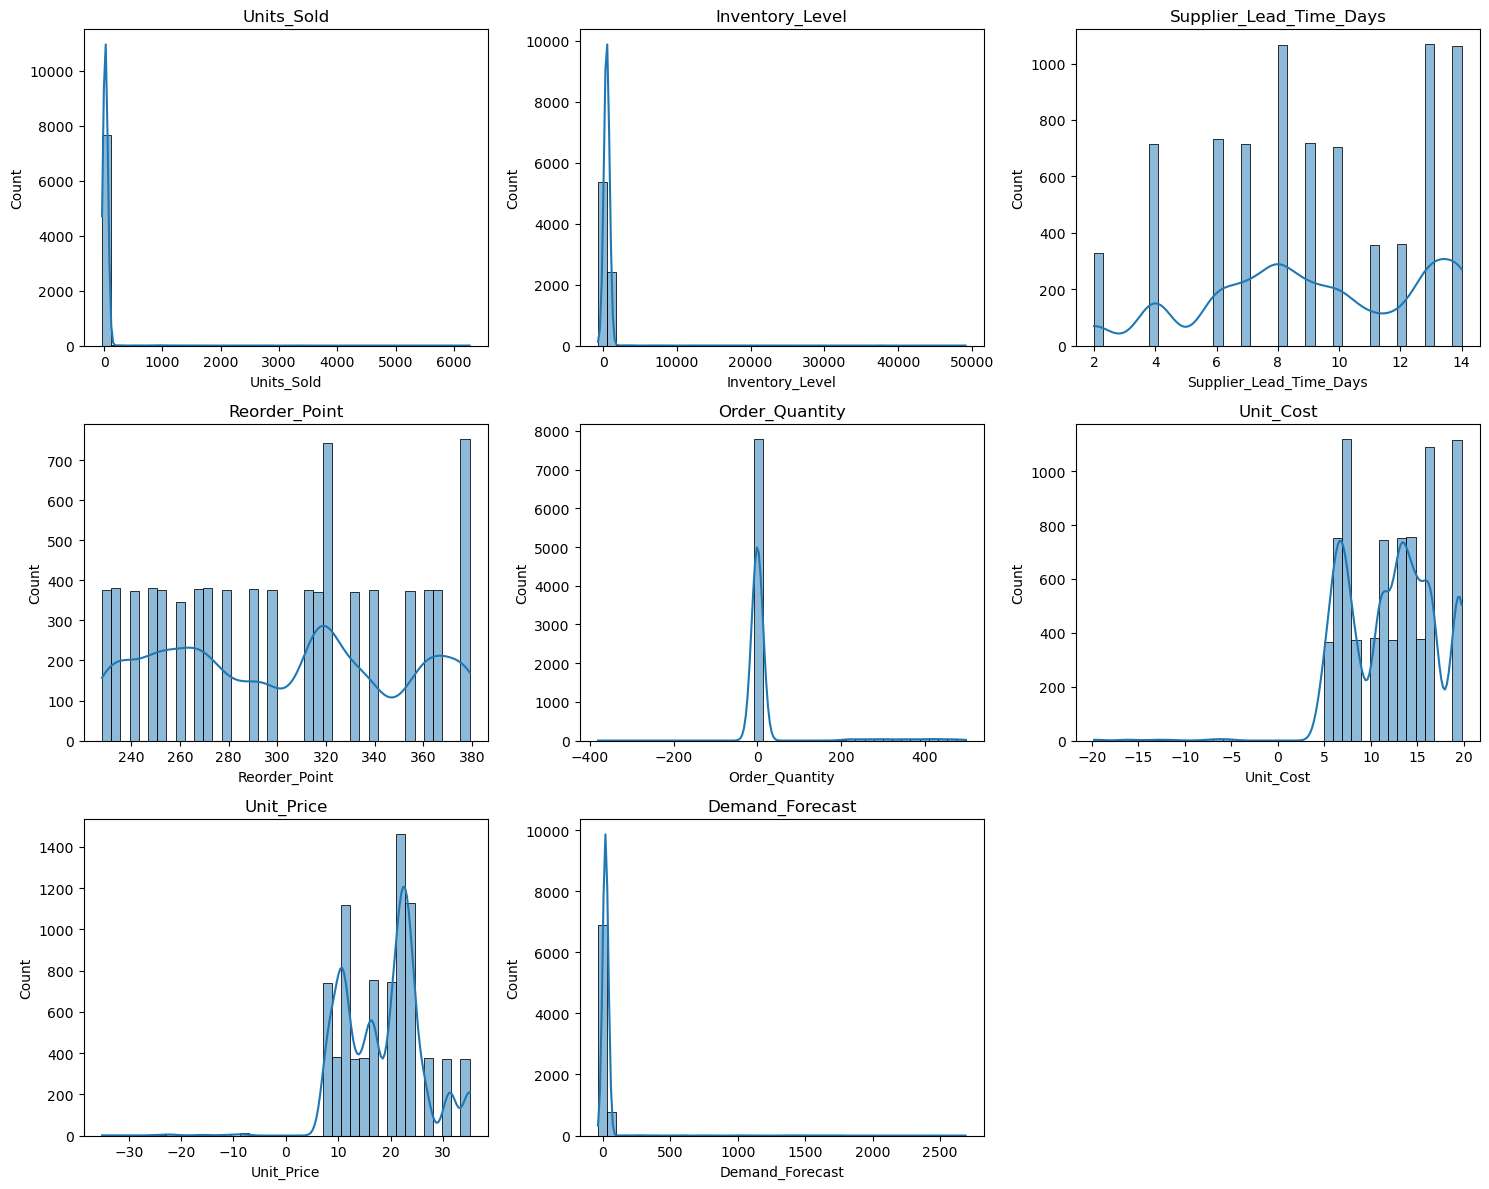

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_cols = [
    "Units_Sold",
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Demand_Forecast"
]

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df_dirty.columns:
        sns.histplot(
            pd.to_numeric(df_dirty[col], errors="coerce"),
            bins=40,
            kde=True,
            ax=axes[i]
        )
        axes[i].set_title(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Boxplots for Outlier Detection

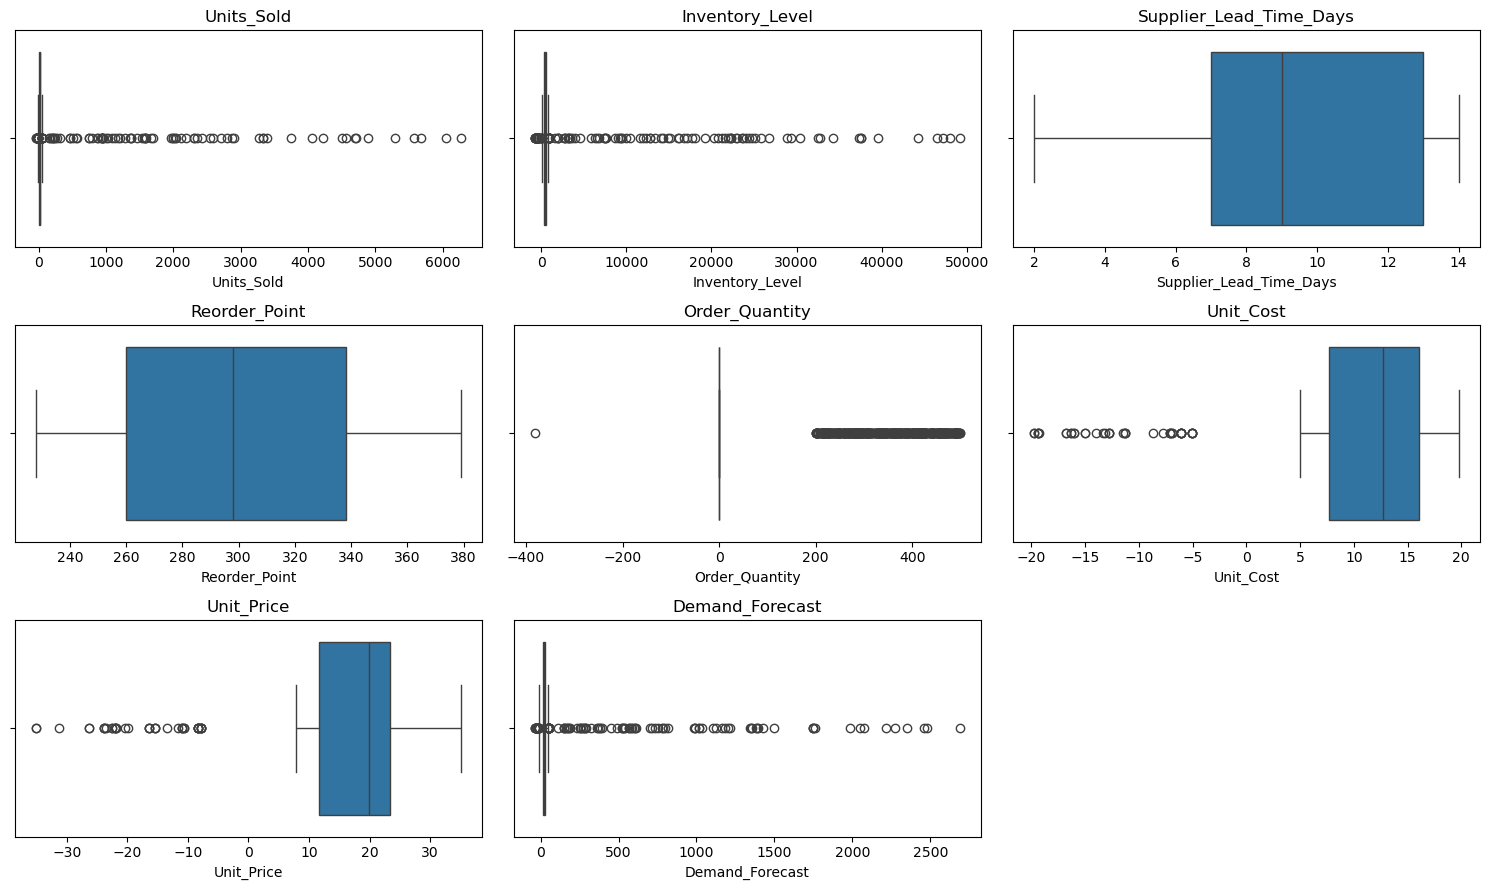

In [26]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df_dirty.columns:
        sns.boxplot(
            x=pd.to_numeric(df_dirty[col], errors="coerce"),
            ax=axes[i],
            orient="h"
        )
        axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Time-Series Demand

A single SKU time series is shown to illustrate seasonality and volatility.

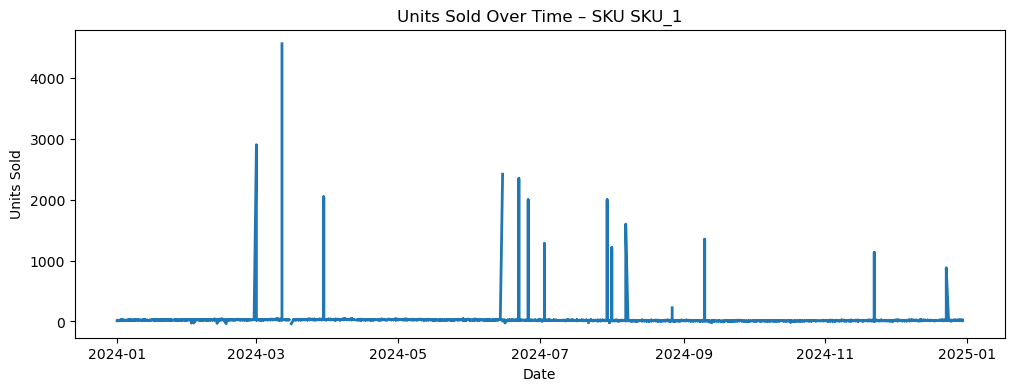

In [27]:
df_dirty["Date"] = pd.to_datetime(df_dirty["Date"], errors="coerce")

sample_sku = df_dirty["SKU_ID"].dropna().unique()[0]
sku_ts = df_dirty[df_dirty["SKU_ID"] == sample_sku].sort_values("Date")

plt.figure(figsize=(12,4))
plt.plot(
    sku_ts["Date"],
    pd.to_numeric(sku_ts["Units_Sold"], errors="coerce"),
    linewidth=2
)
plt.title(f"Units Sold Over Time – SKU {sample_sku}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


## Correlation Heatmap

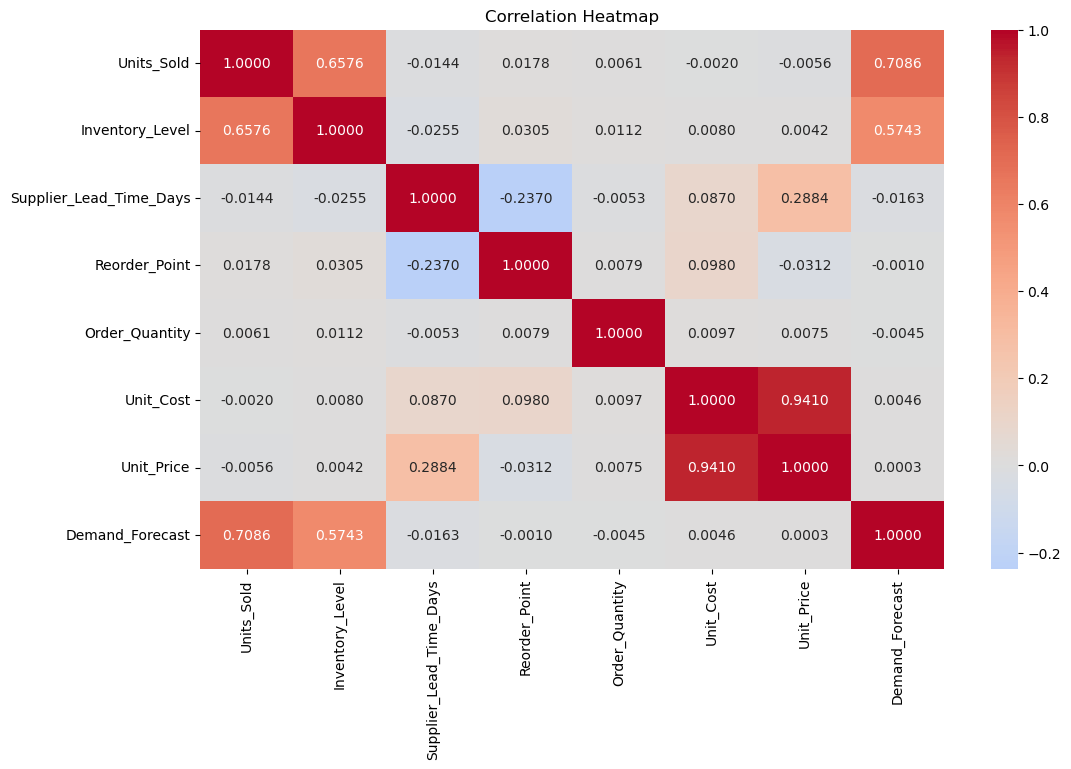

In [28]:
df_corr = df_dirty[numeric_cols].apply(
    lambda x: pd.to_numeric(x, errors="coerce")
)

corr_matrix = df_corr.corr()

plt.figure(figsize=(12,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


## Pairplot

This helps visualize non-linear relationships. These plots are diagnostic

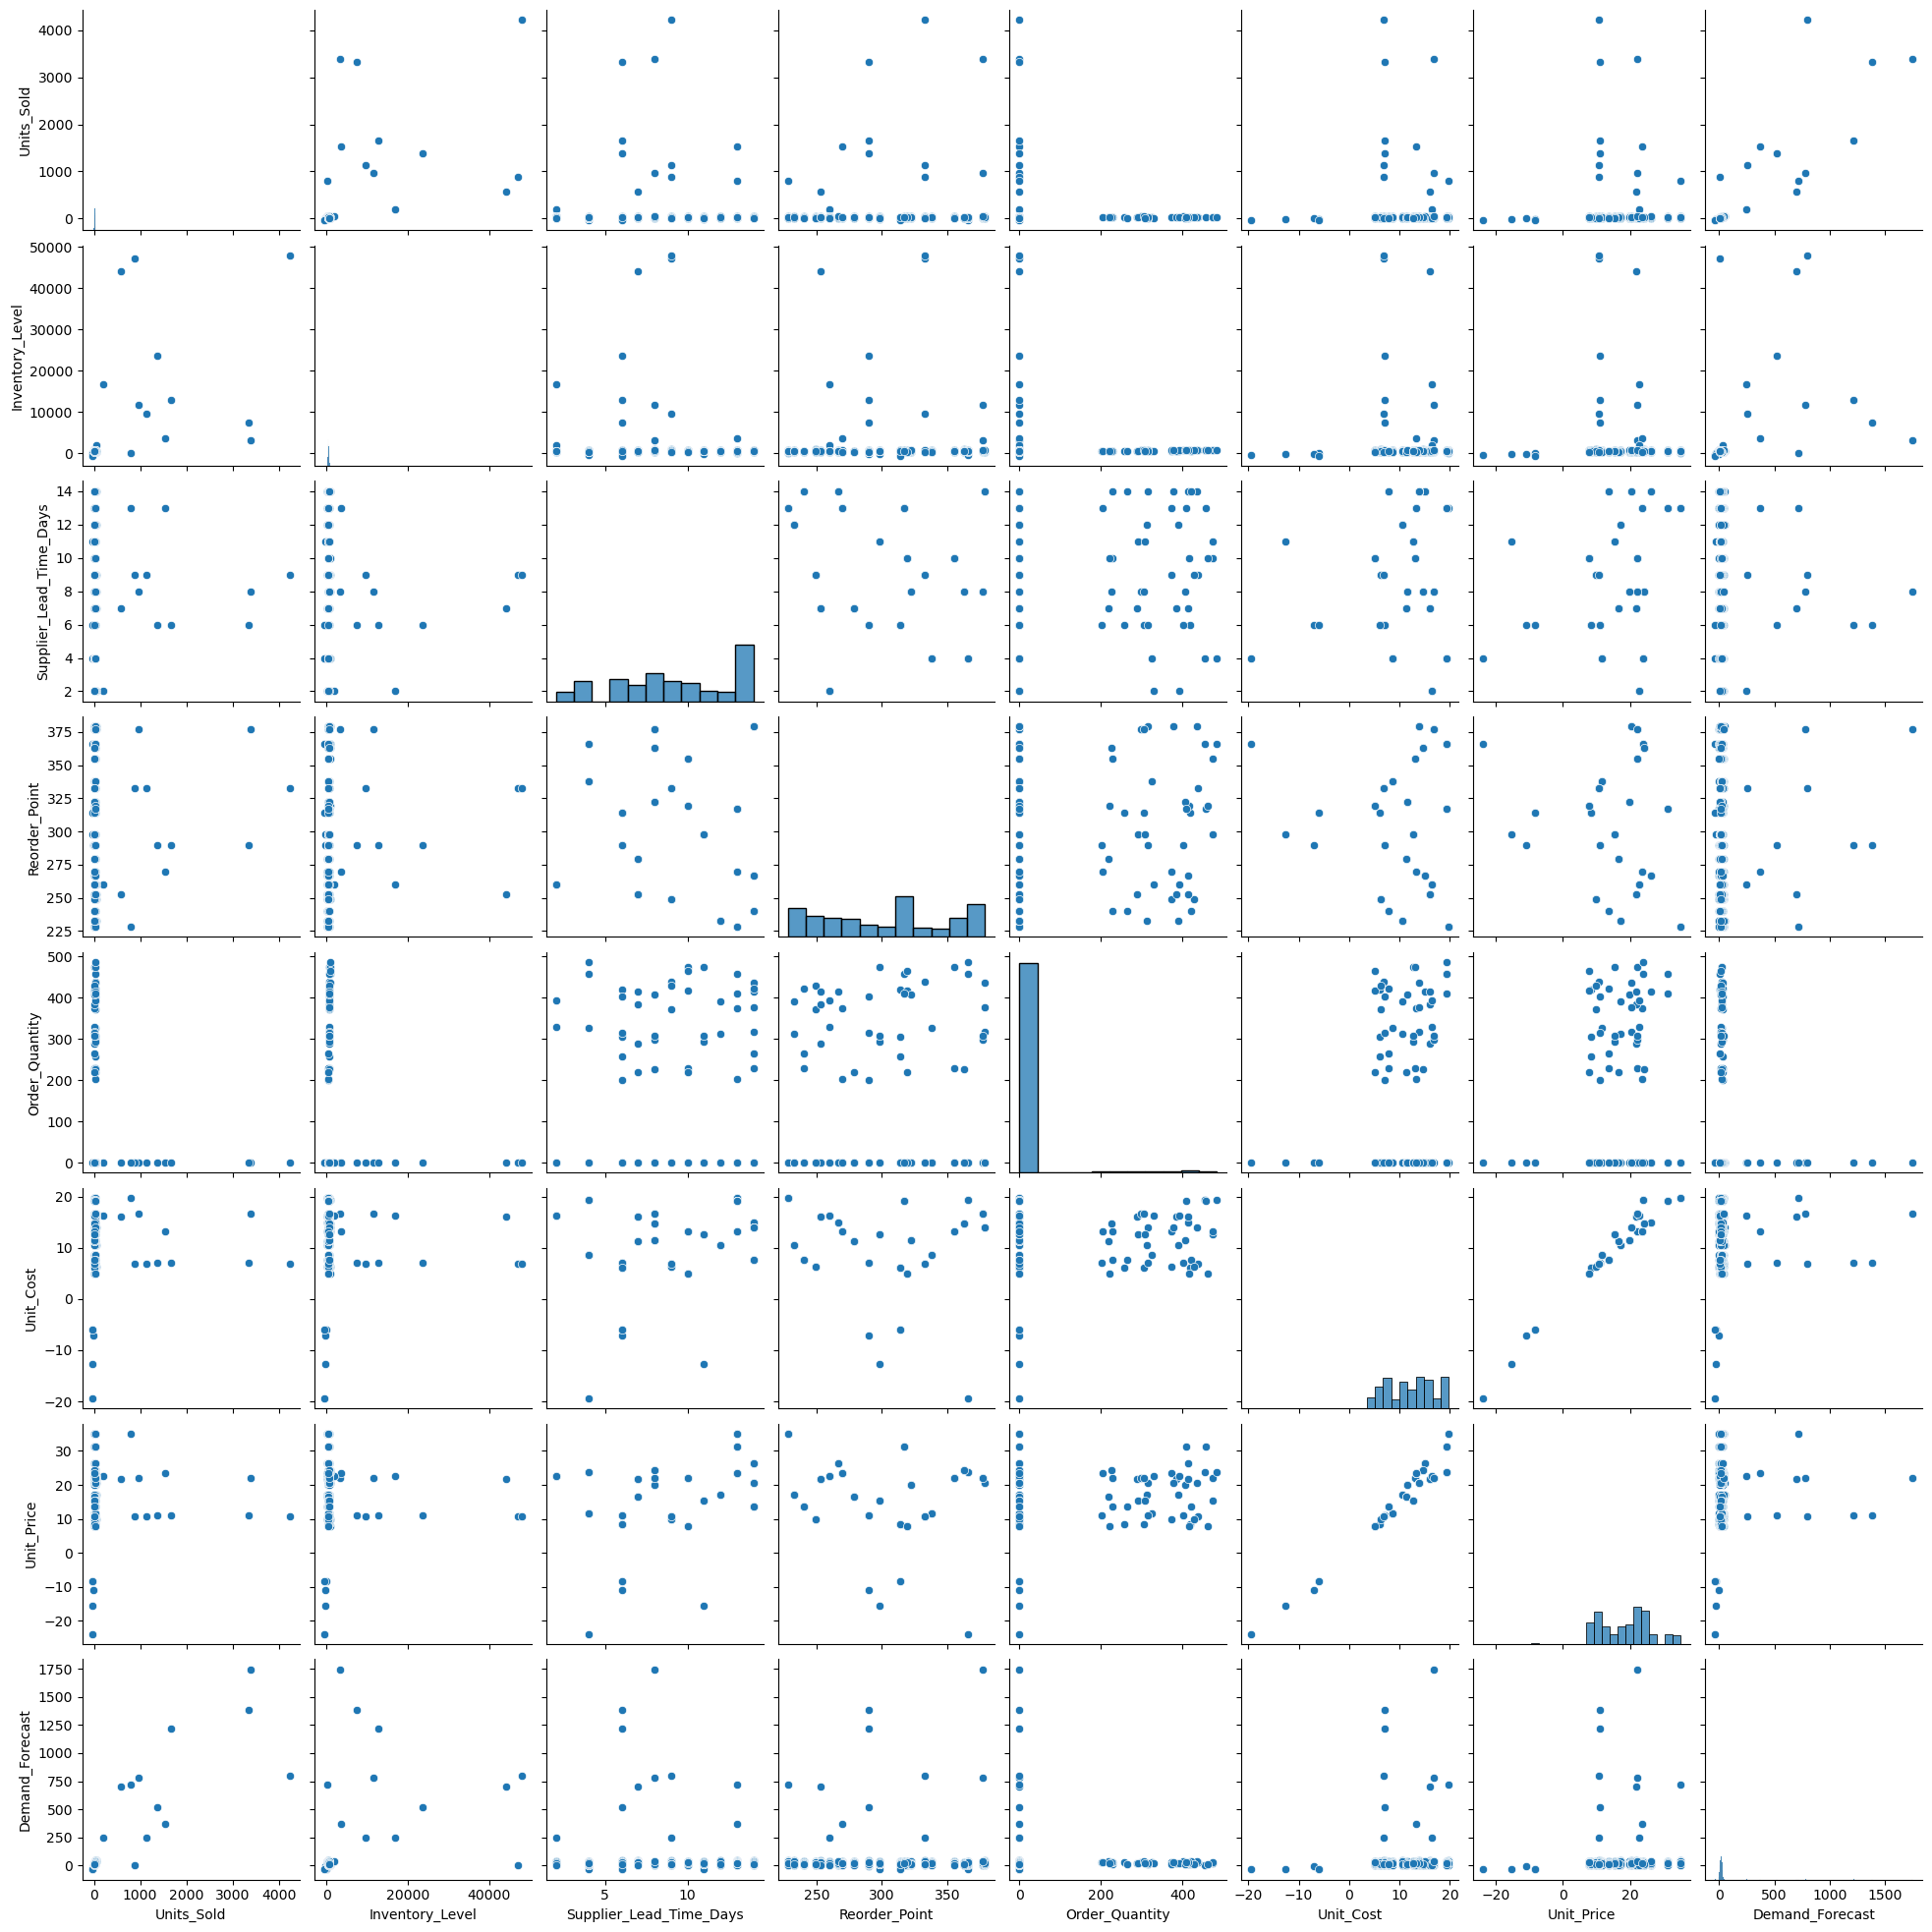

In [29]:
sample_df = df_dirty[numeric_cols].apply(
    lambda x: pd.to_numeric(x, errors="coerce")
).sample(1000, random_state=42)

sns.pairplot(sample_df)
plt.show()


# **2) DATA PREPROCESSING (CLEANING)**

Cleaning goals:
1. Fix data types (especially numeric columns)
2. Parse Date and remove invalid dates
3. Handle duplicates
4. Handle negative values (invalid for many operational metrics)
5. Impute missing values (strategy depends on column type)
6. Prepare clean dataset for feature engineering


## 1) Parse Date & drop invalid dates

In [30]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
before = len(df)
df = df.dropna(subset=["Date"]).copy()
after = len(df)
print(f"Dropped {before - after} rows with invalid dates.")


Dropped 40 rows with invalid dates.


## 2) Convert numeric columns safely

In [31]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


## 3) Remove duplicates

In [32]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)
print(f"Removed {before - after} duplicate rows.")


Removed 0 duplicate rows.


## 4) Handle negative values

We will set negatives to NaN and impute later (instead of blindly taking abs()).

### - Set negatives to NaN

In [33]:
non_negative_cols = ["Units_Sold","Inventory_Level","Demand_Forecast","Order_Quantity","Unit_Cost","Unit_Price"]
for col in non_negative_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan


### - Imputation

- Numeric: median (robust to outliers)
- Categorical: mode
- Flags: fill missing with 0 where appropriate

### a) Impute missing values

In [34]:
# Fill flags first
for col in ["Promotion_Flag","Stockout_Flag"]:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# Numeric median imputation
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Categorical mode imputation
cat_cols = ["SKU_ID","Warehouse_ID","Supplier_ID","Region"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])


Quick check

In [35]:
print("Cleaned shape:", df.shape)
print("Missing % after cleaning:")
((df.isna().mean() * 100).round(2).sort_values(ascending=False)).head(10)


Cleaned shape: (7960, 15)
Missing % after cleaning:


Date                       0.0
SKU_ID                     0.0
Warehouse_ID               0.0
Supplier_ID                0.0
Region                     0.0
Units_Sold                 0.0
Inventory_Level            0.0
Supplier_Lead_Time_Days    0.0
Reorder_Point              0.0
Order_Quantity             0.0
dtype: float64

# 3) **Feature Engineering**

In [36]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['monthly_avg_sales'] = df.groupby(['sku_id', 'year', 'month'])['units_sold'].transform('mean')
df['sales_to_inventory_ratio'] = df['units_sold'] / (df['inventory_level'] + 1e-9)
df['inventory_vs_reorder_gap'] = df['inventory_level'] - df['reorder_point']
print(df[['year','month','day','is_weekend','monthly_avg_sales',
          'sales_to_inventory_ratio','inventory_vs_reorder_gap']].head())

   year  month  day  is_weekend  monthly_avg_sales  sales_to_inventory_ratio  \
0  2024      1    1           0          22.696774                  0.016892   
1  2024      1    2           0          22.696774                  0.029565   
2  2024      1    3           0          22.696774                  0.064815   
3  2024      1    4           0          22.696774                  0.046512   
4  2024      1    5           0          22.696774                  0.042424   

   inventory_vs_reorder_gap  
0                     213.0  
1                     196.0  
2                     161.0  
3                     137.0  
4                     116.0  


**4)XGBoost Regressor:**

In [37]:
X = df[['year','month','day','is_weekend','monthly_avg_sales',
        'sales_to_inventory_ratio','inventory_vs_reorder_gap',
        'inventory_level','supplier_lead_time_days','reorder_point']]
y = df['units_sold'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✔ Mean Absolute Error (MAE): {mae:.2f}")
print(f"✔ Root Mean Square Error (RMSE): {rmse:.2f}")

✔ Mean Absolute Error (MAE): 0.99
✔ Root Mean Square Error (RMSE): 8.40


**RandomForestRegressor**

In [38]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")


Random Forest MAE: 0.78
Random Forest RMSE: 7.58


**Comparison RandomForest & XGBoost**

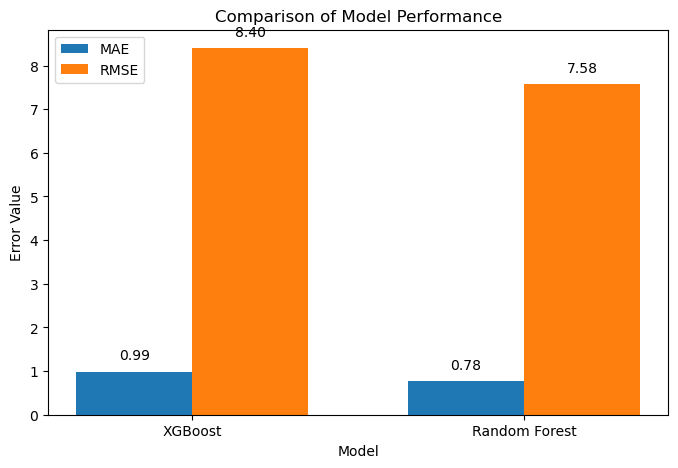

In [39]:
models = ['XGBoost', 'Random Forest']
mae_scores = [0.99, 0.78]      
rmse_scores = [8.40, 7.58]
x = np.arange(len(models))      
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
bar1 = ax.bar(x - width/2, mae_scores, width, label='MAE')
bar2 = ax.bar(x + width/2, rmse_scores, width, label='RMSE')
ax.set_xlabel('Model')
ax.set_ylabel('Error Value')
ax.set_title('Comparison of Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f'{height:.2f}', ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)

plt.show()

# Best Model

Random Forest performed better than XGBoost

Lower MAE (~0.78)

Lower RMSE (~7.58)

This means our predictions for Random Forest are reasonably more accurate for demand forecasting compared to XGBOOST.

In [40]:
#Cross-Validation
scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("CV MAE:", -scores.mean())

CV MAE: 0.5469849246231155


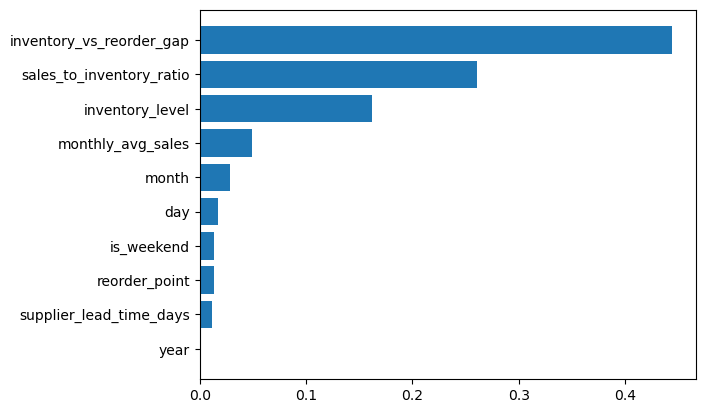

In [41]:
importances = model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)
plt.barh(features[indices], importances[indices])
plt.show()

# Feature Engineering model
inventory_vs_reorder_gap = inventory_level - reorder_point

This is critical because it directly tells us when stock risk occurs.

When the depletion value approaches 0 or becomes negative, inventory is at or below the reorder level.

Since our model predicts units_sold, we can predict the depletion rate.

# What prompts reorder level?

# Inventory will fall below reorder level when:

High predicted demand (units_sold ↑)

Low inventory level

Long supplier lead time

# Stockout Risk 
High during peak seasonal demand

Worse when lead time is long

Triggered when inventory_vs_reorder_gap ≤ 0


# What is our Replenishment Strategy?
Use predictive demand (units_sold forecast)

Reorder when:

Predicted Demand > Available Inventory - Safety Stock


# Inventory Optimization

Increase inventory before:

High-demand months

Weekends

Reduce inventory during low-demand periods

# When Will Inventory Fall Below Reorder Level?

In [42]:
# ============================================================================
# QUESTION 1: When Will Inventory Fall Below Reorder Level?
# ============================================================================
print("\n1. WHEN WILL INVENTORY FALL BELOW REORDER LEVEL?")
print("-" * 50)

# Calculate current depletion rate and predict when stock will fall below reorder level
df['depletion_rate'] = df['monthly_avg_sales'] / 30  # average daily sales

# For each row, calculate days until inventory falls below reorder level
df['days_until_reorder'] = df['inventory_vs_reorder_gap'] / (df['depletion_rate'] + 1e-9)

# Filter for rows where inventory is currently above reorder level but will fall below soon
at_risk = df[df['inventory_vs_reorder_gap'] > 0].copy()
at_risk = at_risk[at_risk['days_until_reorder'] <= 30]  # At risk in next 30 days
at_risk = at_risk.sort_values('days_until_reorder')

print(f"Number of SKU-Warehouse combinations at risk in next 30 days: {len(at_risk)}")
if len(at_risk) > 0:
    print("\nTop 10 most urgent reorder needs:")
    urgent = at_risk.head(10)[['sku_id', 'warehouse_id', 'inventory_level', 
                                'reorder_point', 'inventory_vs_reorder_gap', 
                                'days_until_reorder', 'monthly_avg_sales']]
    print(urgent.to_string(index=False))



1. WHEN WILL INVENTORY FALL BELOW REORDER LEVEL?
--------------------------------------------------
Number of SKU-Warehouse combinations at risk in next 30 days: 438

Top 10 most urgent reorder needs:
sku_id warehouse_id  inventory_level  reorder_point  inventory_vs_reorder_gap  days_until_reorder  monthly_avg_sales
 SKU_2         WH_2            378.0            377                       1.0            0.791909          37.883117
 SKU_1         WH_2            323.0            322                       1.0            0.836653          35.857143
 SKU_3         WH_2            271.0            270                       1.0            1.009836          29.707792
 SKU_3         WH_3            250.0            249                       1.0            1.081395          27.741935
 SKU_1         WH_3            315.0            314                       1.0            1.119457          26.798701
 SKU_5         WH_2            261.0            260                       1.0            1.21212

In [43]:
# ============================================================================
# QUESTION 2: What Prompts Reorder Level?
# ============================================================================
print("\n2. WHAT PROMPTS REORDER LEVEL?")
print("-" * 50)

# Analyze feature importance for reorder triggers
reorder_trigger_df = df[df['order_quantity'] > 0].copy()  # Rows where reorder happened

# Compare features between reorder and non-reorder periods
reorder_features = ['monthly_avg_sales', 'inventory_vs_reorder_gap', 
                    'inventory_level', 'supplier_lead_time_days']

print("Feature differences when reorder is triggered vs not triggered:")
for feature in reorder_features:
    reorder_mean = reorder_trigger_df[feature].mean()
    no_reorder_mean = df[df['order_quantity'] == 0][feature].mean()
    diff_pct = ((reorder_mean - no_reorder_mean) / no_reorder_mean) * 100
    print(f"  {feature}: {diff_pct:+.1f}% different when reorder triggered")



2. WHAT PROMPTS REORDER LEVEL?
--------------------------------------------------
Feature differences when reorder is triggered vs not triggered:
  monthly_avg_sales: +12.9% different when reorder triggered
  inventory_vs_reorder_gap: +73.0% different when reorder triggered
  inventory_level: +27.9% different when reorder triggered
  supplier_lead_time_days: -0.9% different when reorder triggered


In [44]:
# ============================================================================
# QUESTION 3: Stockout Risk Analysis
# ============================================================================
print("\n3. STOCKOUT RISK ANALYSIS")
print("-" * 50)

# Identify high stockout risk
df['stockout_risk'] = np.where(df['inventory_vs_reorder_gap'] <= 0, 1, 0)

# Analyze stockout risk by season and lead time
monthly_risk = df.groupby('month')['stockout_risk'].mean() * 100
print("\nStockout risk by month (%):")
for month, risk in monthly_risk.items():
    print(f"  Month {month}: {risk:.1f}%")

# Stockout risk by lead time
lead_time_risk = df.groupby('supplier_lead_time_days')['stockout_risk'].mean() * 100
print("\nStockout risk by supplier lead time (days):")
for lead_time, risk in lead_time_risk.items():
    if lead_time > 0:
        print(f"  {lead_time:.0f} days: {risk:.1f}%")



3. STOCKOUT RISK ANALYSIS
--------------------------------------------------

Stockout risk by month (%):
  Month 1: 4.1%
  Month 2: 7.9%
  Month 3: 8.8%
  Month 4: 7.0%
  Month 5: 7.1%
  Month 6: 6.7%
  Month 7: 4.3%
  Month 8: 3.7%
  Month 9: 2.9%
  Month 10: 2.7%
  Month 11: 3.7%
  Month 12: 4.2%

Stockout risk by supplier lead time (days):
  2 days: 5.0%
  4 days: 5.3%
  6 days: 5.6%
  7 days: 5.4%
  8 days: 5.1%
  9 days: 5.7%
  10 days: 4.9%
  11 days: 5.2%
  12 days: 4.7%
  13 days: 4.9%
  14 days: 5.3%


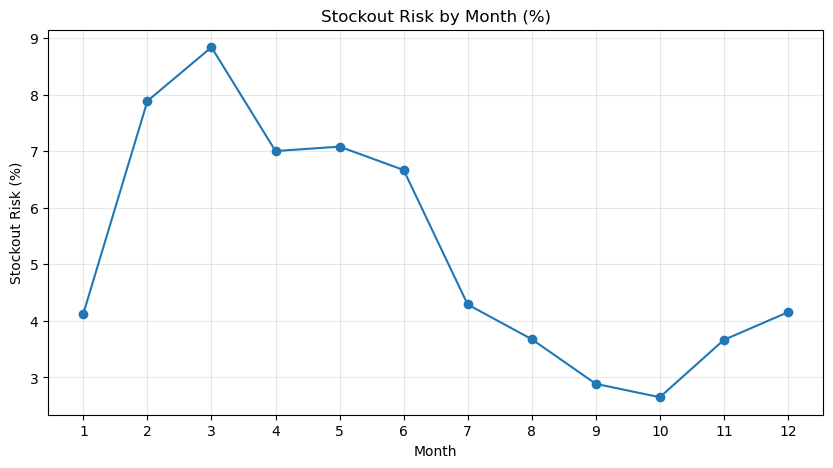

In [45]:
import matplotlib.pyplot as plt

# Calculate monthly stockout risk
monthly_risk = df.groupby('month')['stockout_risk'].mean() * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_risk.index, monthly_risk.values, marker='o')

ax.set_title('Stockout Risk by Month (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Stockout Risk (%)')

ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)

plt.show()

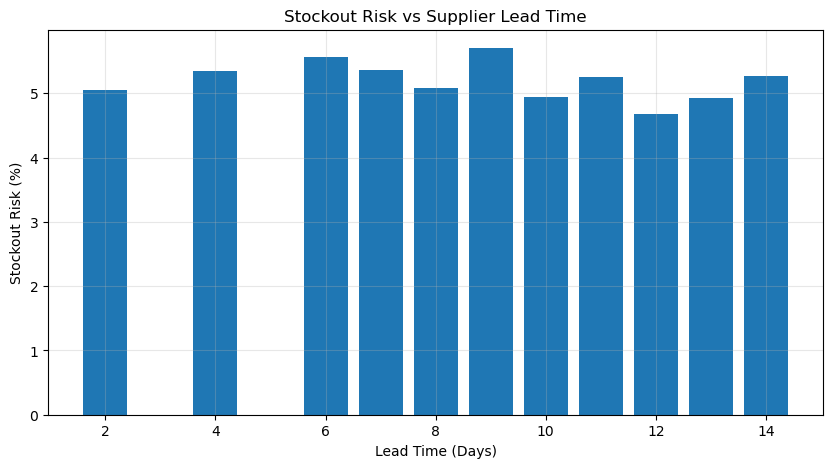

In [46]:
# Calculate risk by lead time
lead_time_risk = df.groupby('supplier_lead_time_days')['stockout_risk'].mean() * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(lead_time_risk.index, lead_time_risk.values)

ax.set_title('Stockout Risk vs Supplier Lead Time')
ax.set_xlabel('Lead Time (Days)')
ax.set_ylabel('Stockout Risk (%)')

ax.grid(True, alpha=0.3)

plt.show()

In [47]:
# ============================================================================
# QUESTION 4: Replenishment Strategy
# ============================================================================
print("\n4. REPLENISHMENT STRATEGY")
print("-" * 50)

# Safety stock calculation (using demand variability)
df['demand_std'] = df.groupby(['sku_id', 'warehouse_id'])['units_sold'].transform('std')
df['safety_stock'] = df['demand_std'] * 1.65  # 95% confidence level

# Reorder point calculation
df['lead_time_demand'] = df['monthly_avg_sales'] / 30 * df['supplier_lead_time_days']
df['calculated_reorder_point'] = df['lead_time_demand'] + df['safety_stock']

# Compare calculated vs actual reorder point
df['reorder_point_diff'] = df['calculated_reorder_point'] - df['reorder_point']

print("Replenishment Strategy Recommendations:")
print("  Reorder when: Predicted Demand > Available Inventory - Safety Stock")
print(f"  Average safety stock needed: {df['safety_stock'].mean():.0f} units")
print(f"  Average reorder point difference (calculated - actual): {df['reorder_point_diff'].mean():.0f}")



4. REPLENISHMENT STRATEGY
--------------------------------------------------
Replenishment Strategy Recommendations:
  Reorder when: Predicted Demand > Available Inventory - Safety Stock
  Average safety stock needed: 34 units
  Average reorder point difference (calculated - actual): -262


In [48]:
# ============================================================================
# QUESTION 5: Inventory Optimization
# ============================================================================
print("\n5. INVENTORY OPTIMIZATION")
print("-" * 50)

# Analyze demand patterns for inventory optimization
monthly_demand = df.groupby('month')['units_sold'].mean()
weekend_demand = df.groupby('is_weekend')['units_sold'].mean()

print("Demand patterns for inventory planning:")
print(f"  Highest demand month: {monthly_demand.idxmax()} (avg sales: {monthly_demand.max():.0f})")
print(f"  Lowest demand month: {monthly_demand.idxmin()} (avg sales: {monthly_demand.min():.0f})")
print(f"  Weekend vs Weekday demand ratio: {weekend_demand[1] / weekend_demand[0]:.2f}")

# Optimization recommendations
print("\nInventory Optimization Recommendations:")
print("  ✓ Increase inventory 2-3 weeks BEFORE high-demand months")
print("  ✓ Increase inventory before weekends if weekend demand > weekday demand")
print("  ✓ Reduce inventory during low-demand periods to minimize holding costs")
print("  ✓ Implement dynamic reorder points based on predicted demand")


5. INVENTORY OPTIMIZATION
--------------------------------------------------
Demand patterns for inventory planning:
  Highest demand month: 3 (avg sales: 33)
  Lowest demand month: 10 (avg sales: 11)
  Weekend vs Weekday demand ratio: 0.96

Inventory Optimization Recommendations:
  ✓ Increase inventory 2-3 weeks BEFORE high-demand months
  ✓ Increase inventory before weekends if weekend demand > weekday demand
  ✓ Reduce inventory during low-demand periods to minimize holding costs
  ✓ Implement dynamic reorder points based on predicted demand


In [49]:
# ============================================================================
# FUTURE PREDICTION: Simulate when inventory will hit reorder level
# ============================================================================
print("\nFUTURE PREDICTION: Simulating 30-day inventory depletion")
print("-" * 50)

# Get the most at-risk SKU-warehouse combination
if len(at_risk) > 0:
    most_at_risk = at_risk.iloc[0]
    print(f"\nMost at-risk: SKU {most_at_risk['sku_id']} at Warehouse {most_at_risk['warehouse_id']}")
    print(f"  Current inventory: {most_at_risk['inventory_level']:.0f} units")
    print(f"  Reorder point: {most_at_risk['reorder_point']:.0f} units")
    print(f"  Gap: {most_at_risk['inventory_vs_reorder_gap']:.0f} units")
    print(f"  Daily sales rate: {most_at_risk['depletion_rate']:.2f} units/day")
    print(f"  Days until reorder: {most_at_risk['days_until_reorder']:.1f} days")
    
    # Predict future sales using the model
    future_X = pd.DataFrame([most_at_risk[features]], columns=features)
    predicted_sales = rf_model.predict(future_X)[0]
    print(f"\n  Predicted sales for next period: {predicted_sales:.0f} units")
    print(f"  Recommendation: REORDER NOW - within {most_at_risk['days_until_reorder']:.0f} days")
else:
    print("No SKU-Warehouse combinations at risk in the next 30 days.")


FUTURE PREDICTION: Simulating 30-day inventory depletion
--------------------------------------------------

Most at-risk: SKU SKU_2 at Warehouse WH_2
  Current inventory: 378 units
  Reorder point: 377 units
  Gap: 1 units
  Daily sales rate: 1.26 units/day
  Days until reorder: 0.8 days

  Predicted sales for next period: 31 units
  Recommendation: REORDER NOW - within 1 days


In [50]:
def analyze_warehouse_risk(df):
    warehouses = df['warehouse_id'].unique()
    warehouse_risk = []

    for warehouse in warehouses:
        warehouse_data = df[df['warehouse_id'] == warehouse]

        sku_risk = []

        for sku in warehouse_data['sku_id'].unique():
            sku_data = warehouse_data[warehouse_data['sku_id'] == sku]
            latest = sku_data.iloc[-1]

            inventory = latest['inventory_level']
            reorder = latest['reorder_point']
            demand = latest['monthly_avg_sales']

            daily = demand / 30 if demand > 0 else 0

            days = (inventory - reorder) / daily if daily > 0 else 0

            sku_risk.append({
                'sku_id': sku,
                'days_until_reorder': days,
                'at_risk': days <= 180
            })

        sku_df = pd.DataFrame(sku_risk)
        at_risk = sku_df[sku_df['at_risk']]

        warehouse_risk.append({
            'warehouse_id': warehouse,
            'total_skus': len(sku_df),
            'at_risk_skus': len(at_risk),
            'risk_percentage': len(at_risk) / len(sku_df) * 100
        })

    return pd.DataFrame(warehouse_risk)

In [51]:
warehouse_risk = analyze_warehouse_risk(df)
warehouse_risk = warehouse_risk.sort_values('risk_percentage', ascending=False)
warehouse_risk

,warehouse_id,total_skus,at_risk_skus,risk_percentage
2,WH_3,4,2,50.0
3,WH_4,4,2,50.0
0,WH_1,5,1,20.0
1,WH_2,5,1,20.0
4,WH_5,4,0,0.0


# Bar Chart

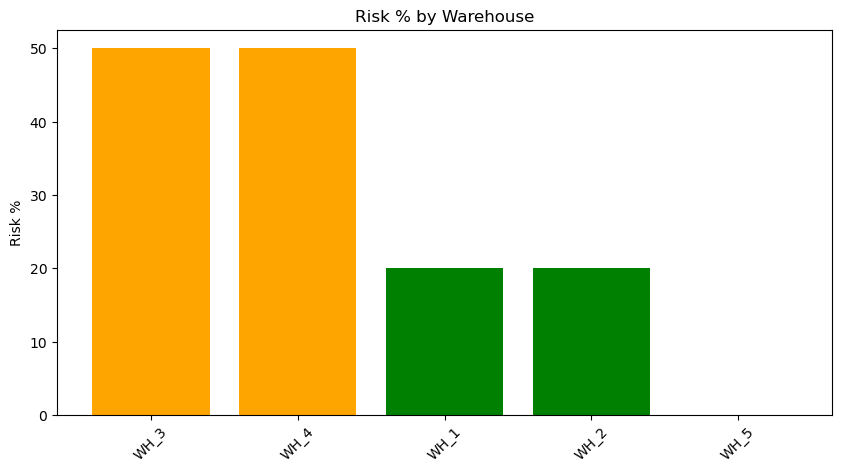

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if p > 50 else 'orange' if p > 25 else 'green'
          for p in warehouse_risk['risk_percentage']]

ax.bar(warehouse_risk['warehouse_id'], warehouse_risk['risk_percentage'], color=colors)

ax.set_title('Risk % by Warehouse')
ax.set_ylabel('Risk %')
plt.xticks(rotation=45)
plt.show()

# Figure 2

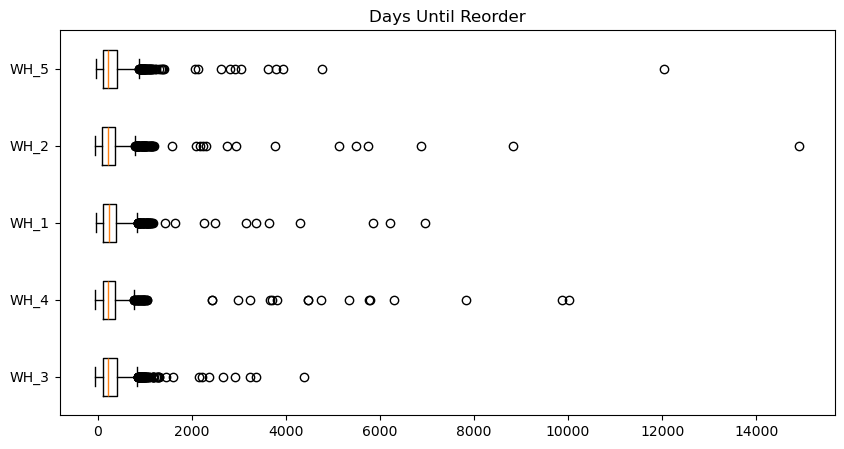

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

warehouse_days = []

for w in warehouse_risk['warehouse_id']:
    data = df[df['warehouse_id'] == w]
    days = (data['inventory_vs_reorder_gap'] /
            (data['monthly_avg_sales']/30 + 1e-9)).dropna()

    warehouse_days.append(days)

ax.boxplot(warehouse_days, labels=warehouse_risk['warehouse_id'], vert=False)

ax.set_title('Days Until Reorder')
plt.show()

# Heatmap

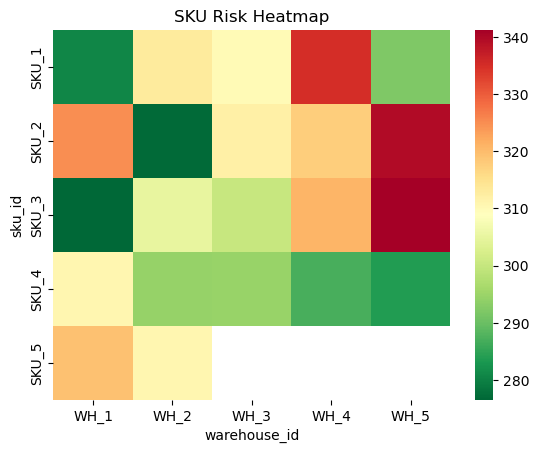

In [54]:
import seaborn as sns

df['days_until_reorder'] = df['inventory_vs_reorder_gap'] / (df['monthly_avg_sales']/30 + 1e-9)

pivot = df.pivot_table(
    index='sku_id',
    columns='warehouse_id',
    values='days_until_reorder'
)

sns.heatmap(pivot, cmap='RdYlGn_r')
plt.title('SKU Risk Heatmap')
plt.show()

In [55]:
for _, row in warehouse_risk.iterrows():
    print(f"{row['warehouse_id']}: {row['risk_percentage']:.1f}% at risk")

WH_3: 50.0% at risk
WH_4: 50.0% at risk
WH_1: 20.0% at risk
WH_2: 20.0% at risk
WH_5: 0.0% at risk


In [56]:
# Scenario 1: Random Split
features = ['year','month','day','is_weekend',
            'monthly_avg_sales',
            'sales_to_inventory_ratio',
            'inventory_vs_reorder_gap',
            'inventory_level',
            'supplier_lead_time_days',
            'reorder_point']

target = 'units_sold'
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                         subsample=0.8, colsample_bytree=0.8,
                         objective='reg:squarederror', random_state=42, n_jobs=-1)

# Random Forest
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("=== Scenario 1: Random Split ===")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}\n")


=== Scenario 1: Random Split ===
Random Forest MAE: 0.78
Random Forest RMSE: 7.58
XGBoost MAE: 0.99
XGBoost RMSE: 8.40



In [57]:
#Scenario 2:High Inventory (> 500 units)
high_inv = df[df['inventory_level'] > 500]
X_high = high_inv[features]
y_high = high_inv[target]

rf_pred_high = rf_model.predict(X_high)
xgb_pred_high = xgb_model.predict(X_high)

print("=== Scenario 2: High Inventory (>500 units) ===")
print(f"Random Forest MAE: {mean_absolute_error(y_high, rf_pred_high):.2f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_high, rf_pred_high)):.2f}")
print(f"XGBoost MAE: {mean_absolute_error(y_high, xgb_pred_high):.2f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_high, xgb_pred_high)):.2f}\n")


=== Scenario 2: High Inventory (>500 units) ===
Random Forest MAE: 0.61
Random Forest RMSE: 5.93
XGBoost MAE: 0.40
XGBoost RMSE: 5.45



In [58]:
#Scenario 3:Promotion Active
promo = df[df['promotion_flag'] == 1]
X_promo = promo[features]
y_promo = promo[target]

rf_pred_promo = rf_model.predict(X_promo)
xgb_pred_promo = xgb_model.predict(X_promo)

print("=== Scenario 3: Promotion Active ===")
print(f"Random Forest MAE: {mean_absolute_error(y_promo, rf_pred_promo):.2f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_promo, rf_pred_promo)):.2f}")
print(f"XGBoost MAE: {mean_absolute_error(y_promo, xgb_pred_promo):.2f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_promo, xgb_pred_promo)):.2f}")

=== Scenario 3: Promotion Active ===
Random Forest MAE: 0.53
Random Forest RMSE: 5.65
XGBoost MAE: 0.40
XGBoost RMSE: 6.11


In [59]:
df.to_csv("final RF predictive.csv", index=False)
